# Capstone Project Module 3
## Bank Marketing Campaign

**Dataset:** `data_bank_marketing_campaign.csv`  
**Jenis masalah:** klasifikasi biner  
**Target:** `deposit` (`yes` / `no`)

Notebook ini mengikuti format **step-by-step end-to-end ML** dengan tetap mempertahankan analisis dan output utama dari notebook sebelumnya.

## 0. Judul

**Memprediksi Keberhasilan Campaign Term Deposit untuk Membantu Bank Memprioritaskan Prospek**

## 1. Import Library dan 2. Load Dataset

Bagian ini memuat seluruh library, fungsi helper, path dataset, dan proses loading data. Konstanta `RANDOM_STATE = 42` digunakan agar hasil split dan training konsisten.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

plt.style.use("default")
pd.set_option("display.max_columns", None)

def engineer_features(df_input):
    """Feature engineering helper agar notebook bisa berjalan tanpa file eksternal."""
    df_fe = df_input.copy()

    df_fe["has_previous_contact"] = (df_fe["pdays"] != -1).astype(int)
    df_fe["pdays_clean"] = df_fe["pdays"].replace(-1, np.nan)
    df_fe["balance_is_negative"] = (df_fe["balance"] < 0).astype(int)
    df_fe["balance_log"] = np.sign(df_fe["balance"]) * np.log1p(np.abs(df_fe["balance"]))

    df_fe["campaign_bucket"] = pd.cut(
        df_fe["campaign"],
        bins=[-np.inf, 1, 2, 4, np.inf],
        labels=["1x", "2x", "3-4x", "5x+"]
    ).astype(str)

    df_fe["age_bucket"] = pd.cut(
        df_fe["age"],
        bins=[0, 25, 35, 45, 55, np.inf],
        labels=["<=25", "26-35", "36-45", "46-55", "55+"]
    ).astype(str)

    return df_fe

# Cari dataset di folder notebook dulu, lalu fallback ke /mnt/data kalau ada.
candidate_paths = [
    Path("data_bank_marketing_campaign.csv"),
    Path("/mnt/data/data_bank_marketing_campaign.csv")
]
DATA_PATH = next((str(p) for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "File data_bank_marketing_campaign.csv tidak ditemukan. "
        "Pastikan CSV ada di folder yang sama dengan notebook atau upload juga file CSV-nya."
    )

MODEL_PATH = "bank_marketing_campaign_model.pkl"

df_raw = pd.read_csv(DATA_PATH)
print(f"Shape dataset awal: {df_raw.shape}")
df_raw.head()


Shape dataset awal: (7813, 11)


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


## 3. Introduction

### 3a. Context
Term deposit adalah produk simpanan berjangka yang hanya dapat dicairkan setelah periode tertentu dan biasanya memberikan bunga tetap. Dalam praktiknya, bank perlu melakukan campaign marketing untuk menawarkan produk ini kepada nasabah.

Tantangannya adalah:
- setiap kontak campaign memiliki biaya dan memakan waktu agen,
- terlalu banyak kontak ke prospek yang kurang potensial menurunkan efisiensi,
- sementara prospek yang sebenarnya potensial bisa terlewat bila tidak diprioritaskan.

Karena itu, model machine learning dapat dipakai sebagai **alat prioritisasi prospek**, bukan sebagai pengganti keputusan bisnis sepenuhnya.

### 3b. Business Problem
Bagaimana cara memprediksi apakah seorang nasabah akan **berlangganan term deposit** berdasarkan profil nasabah dan histori campaign, sehingga tim marketing dapat memprioritaskan kontak ke prospek yang lebih potensial?

### 3c. Goals
1. meningkatkan efektivitas campaign dengan memprioritaskan prospek yang lebih prospektif,
2. mengurangi pemborosan kontak pada nasabah dengan peluang konversi rendah,
3. membantu tim marketing menyusun prioritas follow-up berbasis probability score.

### 3d. Analytical Approach
Karena target `deposit` berupa `yes` / `no`, maka pendekatan yang digunakan adalah **klasifikasi biner**.

### 3e. Stakeholder
- **Tim telemarketing / sales agent**
- **Marketing campaign manager**
- **Manajemen bisnis / investor internal**

### 3f. Metric Selection Based on Goals & Stakeholder
Metric utama yang dipakai adalah **F1-score** agar precision dan recall sama-sama dijaga. Metric pendukung yang tetap diperhatikan adalah **precision**, **recall**, dan **ROC AUC**.

### 3g. 5-point Business ML Formulation
| Komponen | Ringkasan |
|---|---|
| Problem | Campaign belum efisien jika semua prospek diperlakukan sama |
| Data | Profil nasabah + histori interaksi campaign + outcome deposit |
| ML Objective | Memprediksi probabilitas nasabah subscribe term deposit |
| Action | Ranking prospek dan prioritas follow-up |
| Value | Efisiensi biaya kontak dan peningkatan produktivitas agen |

## 4. Data Understanding

### Representasi Data
- **Setiap baris** merepresentasikan **1 observasi nasabah pada campaign**.
- **Setiap kolom** merepresentasikan atribut nasabah, kondisi finansial, atau histori interaksi marketing.
- **Target `deposit`** menunjukkan apakah nasabah akhirnya subscribe term deposit (`yes`) atau tidak (`no`).

### Kaitan Kolom dengan Konteks Bisnis
- **Profil nasabah**: `age`, `job`
- **Kondisi finansial**: `balance`, `housing`, `loan`
- **Riwayat kontak campaign saat ini**: `contact`, `month`, `campaign`
- **Riwayat campaign sebelumnya**: `pdays`, `poutcome`
- **Target**: `deposit`

### Catatan Penting
Dataset yang diberikan berisi **11 kolom**, lebih ringkas dari beberapa versi lain yang beredar. Jadi model hanya dibangun dari informasi yang benar-benar tersedia.

In [ ]:
# 4a. Data Dictionary

data_dictionary = pd.DataFrame({
    "column": [
        "age", "job", "balance", "housing", "loan",
        "contact", "month", "campaign", "pdays", "poutcome", "deposit"
    ],
    "description": [
        "Usia nasabah",
        "Pekerjaan nasabah",
        "Saldo rekening nasabah",
        "Status kepemilikan housing loan",
        "Status personal loan",
        "Jenis media komunikasi terakhir",
        "Bulan kontak terakhir",
        "Jumlah kontak pada campaign saat ini",
        "Jumlah hari setelah dihubungi di campaign sebelumnya (-1 berarti belum pernah)",
        "Hasil campaign sebelumnya",
        "Target: apakah nasabah subscribe term deposit"
    ],
    "type": [
        "numeric", "categorical", "numeric", "categorical", "categorical",
        "categorical", "categorical", "numeric", "numeric", "categorical", "target"
    ]
})

display(data_dictionary)

In [ ]:

print("Informasi umum dataset:")
display(df_raw.info())

summary_table = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_values": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique()
}).sort_index()

display(summary_table)
print(f"Jumlah baris duplikat: {df_raw.duplicated().sum()}")


Informasi umum dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


None

,dtype,missing_values,missing_pct,n_unique
age,int64,0,0.0,75
balance,int64,0,0.0,3153
campaign,int64,0,0.0,32
contact,object,0,0.0,3
deposit,object,0,0.0,2
housing,object,0,0.0,2
job,object,0,0.0,12
loan,object,0,0.0,2
month,object,0,0.0,12
pdays,int64,0,0.0,422


Jumlah baris duplikat: 8


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


,deposit,proportion
0,no,52.23
1,yes,47.77


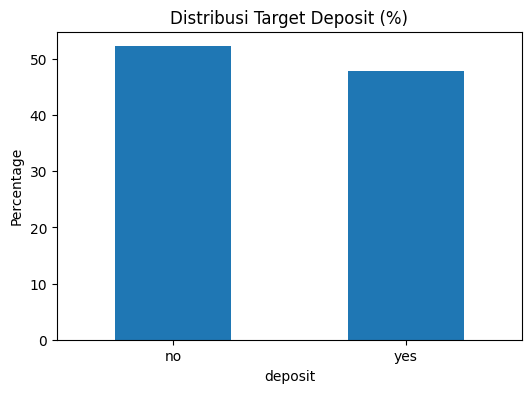

In [ ]:

display(df_raw.head())

target_distribution = (
    df_raw["deposit"]
    .value_counts(normalize=True)
    .rename("proportion")
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"index": "deposit"})
)
display(target_distribution)

ax = (
    df_raw["deposit"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .plot(kind="bar", figsize=(6,4), rot=0, title="Distribusi Target Deposit (%)")
)
ax.set_xlabel("deposit")
ax.set_ylabel("Percentage")
plt.show()


,conversion_rate_pct
contact,
cellular,55.08
telephone,49.45
unknown,22.09


,conversion_rate_pct
poutcome,
success,91.46
other,58.70
failure,51.30
unknown,40.81


,conversion_rate_pct
month,
mar,88.94
dec,88.24
oct,84.97
sep,83.96
apr,62.69
feb,56.37
aug,45.71
jun,44.92
nov,44.14


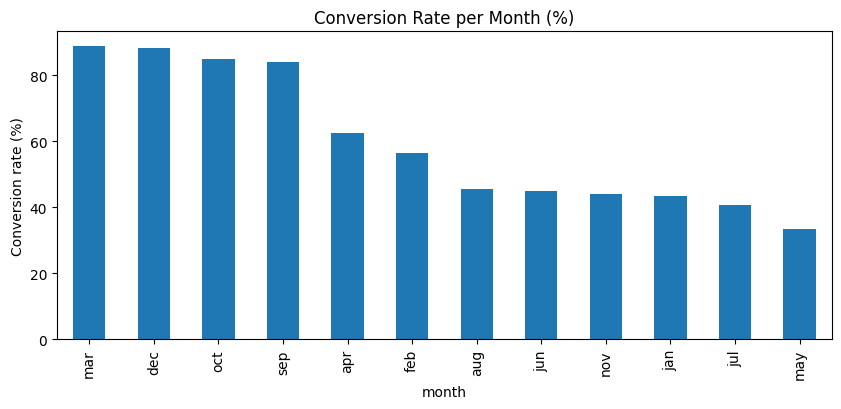

In [ ]:

conversion_contact = (
    df_raw.groupby("contact")["deposit"]
    .apply(lambda s: (s == "yes").mean())
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

conversion_poutcome = (
    df_raw.groupby("poutcome")["deposit"]
    .apply(lambda s: (s == "yes").mean())
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

conversion_month = (
    df_raw.groupby("month")["deposit"]
    .apply(lambda s: (s == "yes").mean())
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

display(conversion_contact.rename("conversion_rate_pct").to_frame())
display(conversion_poutcome.rename("conversion_rate_pct").to_frame())
display(conversion_month.rename("conversion_rate_pct").to_frame())

conversion_month.plot(kind="bar", figsize=(10,4), title="Conversion Rate per Month (%)")
plt.xlabel("month")
plt.ylabel("Conversion rate (%)")
plt.show()


In [ ]:
# 4biii. Imbalance detection
class_pct = df_raw["deposit"].value_counts(normalize=True).mul(100).round(2)
display(class_pct.to_frame("percentage"))

minority_pct = class_pct.min()
print(f"Minority class percentage: {minority_pct:.2f}%")

if minority_pct < 33:
    print("Dataset tergolong imbalanced, sehingga resampling layak dipertimbangkan.")
else:
    print("Dataset relatif seimbang, sehingga resampling tidak menjadi prioritas utama.")

### Insight Awal dari Data Understanding
Beberapa pola awal yang terlihat:
- distribusi target cukup seimbang, sehingga isu imbalance tidak terlalu dominan,
- channel kontak dan outcome campaign sebelumnya terlihat sangat informatif,
- ada indikasi seasonality dari perbedaan conversion rate antar bulan.

Insight ini belum cukup untuk keputusan final, tetapi sudah memberi sinyal fitur mana yang layak diperhatikan saat modeling.

## 5. Data Cleaning

Fokus tahap ini adalah memastikan data layak digunakan untuk modeling. Prinsip pentingnya: tidak semua nilai ekstrem harus dibuang. Dalam data perbankan, balance yang sangat tinggi atau sangat rendah bisa saja merupakan kondisi bisnis yang valid.

In [ ]:

df = df_raw.drop_duplicates().copy()

print(f"Jumlah baris sebelum drop duplicates : {len(df_raw)}")
print(f"Jumlah baris duplikat               : {df_raw.duplicated().sum()}")
print(f"Jumlah baris setelah cleaning       : {len(df)}")

numeric_summary = df[["age", "balance", "campaign", "pdays"]].describe().T
numeric_summary["iqr"] = numeric_summary["75%"] - numeric_summary["25%"]
display(numeric_summary)

quantiles = df[["age", "balance", "campaign", "pdays"]].quantile([0.01, 0.05, 0.95, 0.99]).T
display(quantiles)


Jumlah baris sebelum drop duplicates : 7813
Jumlah baris duplikat               : 8
Jumlah baris setelah cleaning       : 7805


,count,mean,std,min,25%,50%,75%,max,iqr
age,7805.0,41.257783,11.922833,18.0,32.0,39.0,49.0,95.0,17.0
balance,7805.0,1513.968225,3090.508938,-6847.0,128.0,550.0,1685.0,66653.0,1557.0
campaign,7805.0,2.520564,2.728204,1.0,1.0,2.0,3.0,63.0,2.0
pdays,7805.0,51.462268,108.115084,-1.0,-1.0,-1.0,41.0,854.0,42.0


,0.01,0.05,0.95,0.99
age,22.0,26.0,62.0,77.00
balance,-522.0,-55.8,6138.0,13334.56
campaign,1.0,1.0,7.0,13.00
pdays,-1.0,-1.0,323.0,420.96


### Keputusan Data Cleaning
- Menghapus duplicate rows agar observasi yang sama tidak dihitung berulang.
- Tidak melakukan imputasi langsung di data mentah karena tidak ada missing value eksplisit.
- Kategori `unknown` dipertahankan sebagai kategori valid.
- Outlier numerik tidak dibuang agresif, melainkan ditangani lewat feature engineering dan model choice.

## 6. Define X and Y

Setelah cleaning selesai, data dipisahkan menjadi:
- `X` sebagai fitur input
- `y` sebagai target biner (`yes` = 1, `no` = 0)

In [ ]:

X = df.drop(columns="deposit")
y = (df["deposit"] == "yes").astype(int)

X_engineered = engineer_features(X)
print("Kolom sebelum feature engineering:")
print(X.columns.tolist())
print("\nKolom setelah feature engineering:")
print(X_engineered.columns.tolist())

display(X_engineered.head())

numeric_cols = X_engineered.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_engineered.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumeric columns:")
print(numeric_cols)
print("\nCategorical columns:")
print(categorical_cols)


Kolom sebelum feature engineering:
['age', 'job', 'balance', 'housing', 'loan', 'contact', 'month', 'campaign', 'pdays', 'poutcome']

Kolom setelah feature engineering:
['age', 'job', 'balance', 'housing', 'loan', 'contact', 'month', 'campaign', 'pdays', 'poutcome', 'has_previous_contact', 'pdays_clean', 'balance_is_negative', 'campaign_bucket', 'age_bucket', 'balance_log']


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,has_previous_contact,pdays_clean,balance_is_negative,campaign_bucket,age_bucket,balance_log
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,0,NaN,0,2_3_contacts,50_59,7.416378
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,0,NaN,1,2_3_contacts,30_39,-8.025843
2,51,admin.,3025,no,no,cellular,may,1,352,other,1,352.0,0,1_contact,50_59,8.014997
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,0,NaN,1,1_contact,30_39,-4.477337
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,0,NaN,0,4_5_contacts,30_39,5.327876



Numeric columns:
['age', 'balance', 'campaign', 'pdays', 'has_previous_contact', 'pdays_clean', 'balance_is_negative', 'balance_log']

Categorical columns:
['job', 'housing', 'loan', 'contact', 'month', 'poutcome', 'campaign_bucket', 'age_bucket']


## 7. Data Splitting

Data dibagi menjadi **train**, **validation**, dan **test** dengan stratifikasi agar proporsi target tetap konsisten di setiap subset.

In [ ]:

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

print(f"Train size      : {len(X_train)}")
print(f"Validation size : {len(X_val)}")
print(f"Test size       : {len(X_test)}")


Train size      : 4683
Validation size : 1561
Test size       : 1561


## 8. Feature Engineering dan Pipeline

### 8a. Numerical vs Categorical Treatment
- fitur numerik: imputasi median + scaling
- fitur kategorikal: imputasi most frequent + one-hot encoding

### 8b. Feature Engineering Tambahan
- `has_previous_contact`
- `pdays_clean`
- `balance_is_negative`
- `balance_log`
- `campaign_bucket`
- `age_bucket`

### 8c. Pipeline Utama
Seluruh proses feature engineering, preprocessing, dan modeling digabung dalam pipeline agar konsisten dan lebih aman dari data leakage.

In [ ]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

def build_pipeline(model):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    return Pipeline(steps=[
        ("feature_engineering", FunctionTransformer(engineer_features, validate=False)),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=8, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []
for model_name, model in candidate_models.items():
    pipeline = build_pipeline(model)
    scores = cross_validate(pipeline, X_trainval, y_trainval, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)
display(cv_results.round(4))


,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,0.7258,0.7716,0.6062,0.6787,0.7789
1,Random Forest,0.7131,0.7314,0.6322,0.6781,0.7727
2,Logistic Regression,0.7053,0.7188,0.6308,0.6717,0.7697
3,Decision Tree,0.6733,0.7582,0.4938,0.5826,0.7215


## 9. Model Benchmarking

Model yang dibandingkan dalam notebook ini:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Benchmarking dilakukan dengan cross-validation dan dievaluasi menggunakan accuracy, precision, recall, F1-score, dan ROC AUC.

## 9I. Resampling Technique

Karena distribusi target pada dataset ini relatif seimbang, resampling tidak dijadikan fokus utama. Menambahkan ROS, RUS, atau SMOTE dalam kondisi ini justru berisiko memberi kompleksitas tambahan tanpa manfaat yang jelas.

## 9II. Penalized Model

Pendekatan penalized diterapkan lewat `class_weight='balanced'` pada Logistic Regression dan Random Forest, untuk melihat apakah pembobotan kelas membantu trade-off performa walaupun dataset tidak terlalu imbalanced.

Final model berdasarkan CV: Gradient Boosting


,threshold,precision,recall,f1
0,0.41,0.685030,0.766756,0.723593
1,0.42,0.694205,0.754692,0.723186
2,0.46,0.730399,0.711796,0.720978
3,0.47,0.739377,0.699732,0.719008
4,0.40,0.663636,0.782842,0.718327
5,0.39,0.652747,0.796247,0.717391
6,0.45,0.716198,0.717158,0.716678
7,0.48,0.747813,0.687668,0.716480
8,0.44,0.705729,0.726542,0.715984
9,0.43,0.698089,0.734584,0.715872


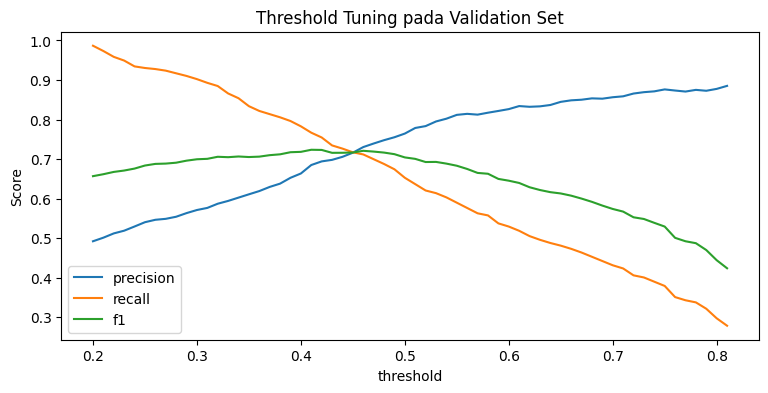

Threshold terbaik berdasarkan validation F1: 0.41


In [ ]:

best_model_name = cv_results.iloc[0, 0]
print(f"Final model berdasarkan CV: {best_model_name}")

best_pipeline = build_pipeline(candidate_models[best_model_name])
best_pipeline.fit(X_train, y_train)

val_proba = best_pipeline.predict_proba(X_val)[:, 1]

threshold_candidates = np.arange(0.20, 0.81, 0.01)
threshold_eval = []

for thr in threshold_candidates:
    val_pred = (val_proba >= thr).astype(int)
    threshold_eval.append({
        "threshold": round(float(thr), 2),
        "precision": precision_score(y_val, val_pred),
        "recall": recall_score(y_val, val_pred),
        "f1": f1_score(y_val, val_pred)
    })

threshold_df = pd.DataFrame(threshold_eval).sort_values(
    ["f1", "precision", "recall"], ascending=False
).reset_index(drop=True)

best_threshold = float(threshold_df.iloc[0]["threshold"])
display(threshold_df.head(10))

threshold_plot = threshold_df.sort_values("threshold")
threshold_plot.plot(x="threshold", y=["precision", "recall", "f1"], figsize=(9,4), title="Threshold Tuning pada Validation Set")
plt.ylabel("Score")
plt.show()

print(f"Threshold terbaik berdasarkan validation F1: {best_threshold:.2f}")


## 10. Evaluasi Final pada Test Set

Model terbaik dari tahap benchmarking digunakan untuk evaluasi final. Hasil dibandingkan pada threshold default dan threshold yang dioptimalkan dari validation set.

In [ ]:

final_pipeline = build_pipeline(candidate_models[best_model_name])
final_pipeline.fit(X_trainval, y_trainval)

test_proba = final_pipeline.predict_proba(X_test)[:, 1]

evaluation_rows = []
for setting, threshold in [("Default 0.50", 0.50), ("Optimized", best_threshold)]:
    test_pred = (test_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, test_pred)
    evaluation_rows.append({
        "setting": setting,
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred),
        "recall": recall_score(y_test, test_pred),
        "f1": f1_score(y_test, test_pred),
        "roc_auc": roc_auc_score(y_test, test_proba),
        "tn": cm[0, 0],
        "fp": cm[0, 1],
        "fn": cm[1, 0],
        "tp": cm[1, 1]
    })

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df.round(4))


,setting,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Default 0.50,0.50,0.7354,0.7817,0.6193,0.6911,0.7891,686,129,284,462
1,Optimized,0.41,0.7092,0.6776,0.7466,0.7105,0.7891,550,265,189,557


## 11. Check the Model (Can We Trust It or Not)

### 11a. Confusion Matrix
Digunakan untuk melihat trade-off antara false positive dan false negative, lalu menerjemahkannya ke biaya kontak dan peluang prospek yang terlewat.

### 11b. Explainability
Karena final model bersifat non-linear, interpretasi fitur dilakukan dengan permutation importance.

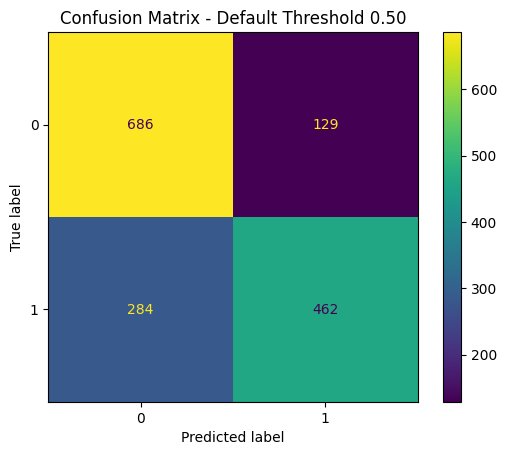

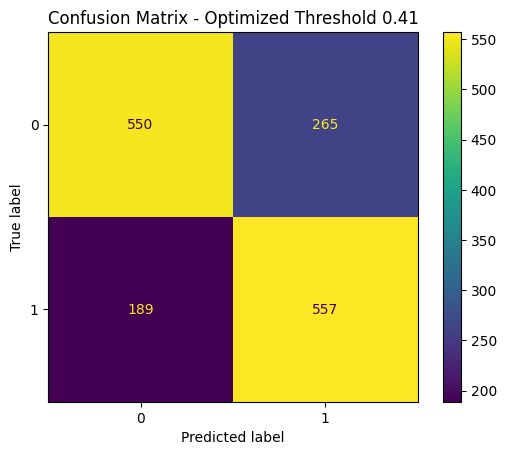

In [ ]:

# Confusion matrix default threshold
default_pred = (test_proba >= 0.50).astype(int)
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, default_pred))
disp.plot()
plt.title("Confusion Matrix - Default Threshold 0.50")
plt.show()

# Confusion matrix optimized threshold
optimized_pred = (test_proba >= best_threshold).astype(int)
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, optimized_pred))
disp.plot()
plt.title(f"Confusion Matrix - Optimized Threshold {best_threshold:.2f}")
plt.show()


,feature,importance_mean,importance_std
6,month,0.0415,0.0062
5,contact,0.0316,0.0064
9,poutcome,0.0254,0.0029
2,balance,0.0209,0.0077
0,age,0.0209,0.0061
3,housing,0.0097,0.0037
8,pdays,0.0083,0.0059
4,loan,0.0062,0.0034
7,campaign,0.0007,0.0031
1,job,0.0007,0.0039


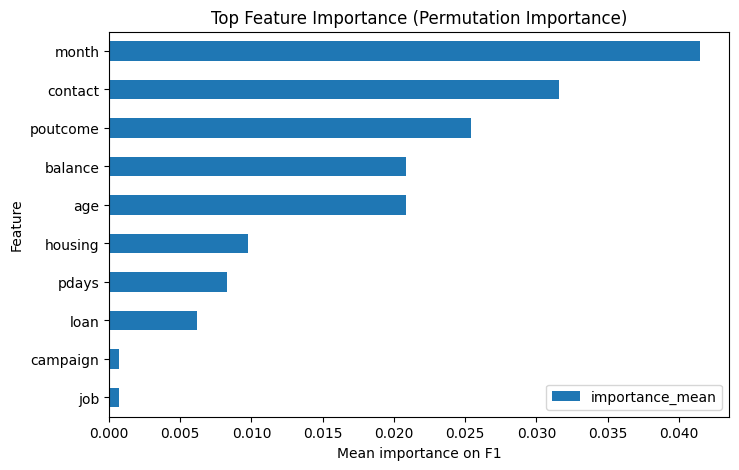

In [ ]:

perm_result = permutation_importance(
    final_pipeline, X_test, y_test,
    n_repeats=8, random_state=42, scoring="f1", n_jobs=1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df.round(4))

importance_df.head(10).sort_values("importance_mean").plot(
    x="feature", y="importance_mean", kind="barh", figsize=(8,5),
    title="Top Feature Importance (Permutation Importance)"
)
plt.xlabel("Mean importance on F1")
plt.ylabel("Feature")
plt.show()


## 12. Scoring Example dan Penyimpanan Artifact

Bagian ini menunjukkan contoh prospek dengan probabilitas tertinggi sekaligus menyimpan model untuk kebutuhan deployment sederhana.

In [ ]:

scored_test = X_test.copy()
scored_test["actual"] = y_test.values
scored_test["predicted_proba_yes"] = test_proba
scored_test["predicted_label_optimized"] = optimized_pred
display(
    scored_test.sort_values("predicted_proba_yes", ascending=False).head(10)
)

artifact = {
    "model": final_pipeline,
    "threshold": best_threshold,
    "target_mapping": {0: "no", 1: "yes"},
    "feature_note": "Model expects raw feature columns from the provided dataset schema."
}
with open(MODEL_PATH, "wb") as f:
    pickle.dump(artifact, f)
print(f"Model artifact saved to: {MODEL_PATH}")


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,actual,predicted_proba_yes,predicted_label_optimized
4939,43,services,774,no,no,cellular,mar,1,421,success,1,0.984531,1
6977,64,retired,48,no,no,cellular,sep,3,92,success,1,0.970612,1
4165,60,management,315,no,no,cellular,sep,1,183,success,1,0.967247,1
417,35,technician,294,yes,no,cellular,mar,1,90,success,1,0.965445,1
1621,37,management,1113,no,no,cellular,mar,1,182,success,1,0.964089,1
961,69,retired,324,no,no,cellular,aug,1,189,success,0,0.963534,1
4427,44,management,282,no,no,cellular,mar,2,154,success,1,0.961365,1
6119,36,services,52,yes,no,cellular,mar,2,179,success,1,0.961353,1
6578,55,management,2587,no,no,cellular,sep,2,94,success,1,0.959313,1
638,38,services,2678,no,no,cellular,sep,2,187,success,1,0.958773,1


Model artifact saved to: bank_marketing_campaign_model.joblib


## 13. Kesimpulan dan Rekomendasi

### Kesimpulan
Project ini berhasil membangun model klasifikasi untuk memprediksi kemungkinan nasabah membuka term deposit berdasarkan data campaign yang tersedia.

### Ringkasan hasil utama
- model terbaik dipilih berdasarkan hasil cross-validation,
- threshold default dan optimized memberi trade-off bisnis yang berbeda,
- model paling cocok digunakan sebagai **decision support tool** untuk prioritisasi prospek.

### Kapan Model Bisa Dipercaya
- ketika data baru masih mirip dengan pola historis,
- ketika model dipakai untuk ranking atau prioritisasi, bukan keputusan absolut.

### Kapan Model Kurang Bisa Dipercaya
- ketika strategi campaign berubah drastis,
- ketika distribusi data bergeser,
- ketika ada fitur bisnis penting yang belum tersedia di dataset.

### Rekomendasi
1. gunakan probability score untuk ranking prospek,
2. sesuaikan threshold dengan kapasitas agen,
3. lakukan evaluasi berkala dan monitoring drift,
4. pertimbangkan penambahan fitur biaya campaign dan revenue di masa depan.

## 14. Improvement ke Depan

Peningkatan yang masih terbuka:
- benchmarking model yang lebih luas seperti KNN, AdaBoost, LightGBM, atau XGBoost,
- hyperparameter tuning yang lebih mendalam,
- probability calibration,
- cost-sensitive learning,
- explainability lanjutan seperti SHAP.

## 15. Simpan Model Final

Artifact model sudah disimpan dalam format `.pkl`. Untuk deployment yang lebih formal, model dapat dilatih ulang pada seluruh data bersih sebelum final handoff.